In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv('Census.csv')

In [3]:
df_clustering = df.copy()

In [4]:
df_clustering = df_clustering.sample(frac=0.2, random_state=23)

In [5]:
df_clustering = df_clustering.replace(-9, 'Not Applicable')

In [6]:
for col in df_clustering.select_dtypes('object').columns:
    df_clustering[col] = df_clustering[col].astype('category')

In [7]:
df_clustering['No of hours'] = pd.to_numeric(df_clustering['No of hours'], errors='coerce')
df_clustering = df_clustering.dropna(subset=['No of hours']).copy()

In [8]:
features_clustering = df_clustering.columns.difference(['Region', 'Person ID', 'Population Base', 'Hours worked per week', 'Approximated Social Grade']).tolist()
X_cluster = df_clustering[features_clustering]

In [9]:
X_cluster.head()

,Age,Country of Birth,Economic Activity,Ethnic Group,Family Composition,Health,Industry,Marital Status,No of hours,Occupation,Religion,Residence Type,Sex,Student
498819,5,1,1,1,3,2,10,4,34.0,3,1,H,2,2
440616,5,2,1,1,3,2,4,3,34.0,5,2,H,1,2
556829,4,2,2,3,2,1,4,2,55.0,1,6,H,1,2
501558,5,1,4,1,2,3,10,2,42.0,1,1,H,2,1
336094,4,1,2,1,2,1,4,2,18.0,1,2,H,2,2


In [10]:
categorical_features_cluster = X_cluster.select_dtypes(include=['object', 'int64']).columns.tolist()
numerical_features_cluster = ['No of hours']

In [11]:
preprocessor_cluster = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features_cluster),
        ('num', StandardScaler(), numerical_features_cluster)
    ],
    remainder='drop'
)

In [12]:
X_scaled_encoded = preprocessor_cluster.fit_transform(X_cluster)

In [13]:
print("\nFitting PCA to determine optimal number of components (retain 95% variance)...")
if hasattr(X_scaled_encoded, "toarray"):
    X_dense = X_scaled_encoded.toarray()
else:
    X_dense = X_scaled_encoded

pca = PCA(n_components=0.95, random_state=23)
X_pca = pca.fit_transform(X_dense)

print(f"Number of PCA components selected: {pca.n_components_}")


Fitting PCA to determine optimal number of components (retain 95% variance)...
Number of PCA components selected: 8


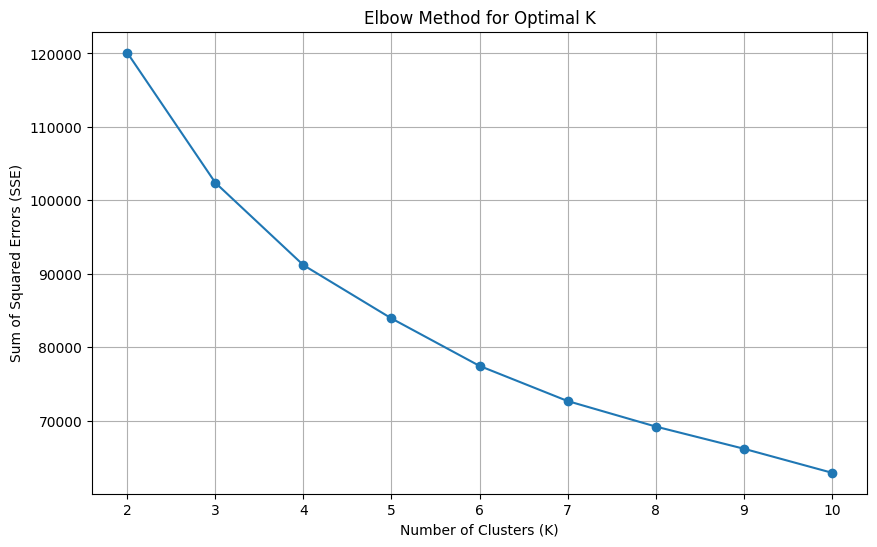

In [14]:
sse = []
k_range = range(2, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=23, n_init=10)
    kmeans.fit(X_scaled_encoded)
    sse.append(kmeans.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(k_range, sse, marker='o')
plt.title('Elbow Method for Optimal K')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Sum of Squared Errors (SSE)')
plt.xticks(k_range)
plt.grid(True)
plt.show()

In [15]:
optimal_k = 5

In [16]:
print("\nK-Means Clustering (on PCA data)")
kmeans_model = KMeans(n_clusters=optimal_k, random_state=23, n_init=10)
clusters_kmeans = kmeans_model.fit_predict(X_pca)
df_clustering['KMeans_Cluster'] = clusters_kmeans

sil_kmeans = silhouette_score(X_pca, clusters_kmeans)
print(f"Silhouette Score (KMeans): {sil_kmeans:.3f}")

print("\nK-Means Cluster Characteristics:")
for i in range(optimal_k):
    cluster_data = df_clustering[df_clustering['KMeans_Cluster'] == i]
    print(f"\n--- Cluster {i} ---")
    print(f"Size: {len(cluster_data)} ({len(cluster_data)/len(df_clustering):.1%})")
    print("Dominant Age Group:", cluster_data['Age'].mode()[0])
    print("Dominant Economic Activity:", cluster_data['Economic Activity'].mode()[0])
    print("Average No of hours:", f"{cluster_data['No of hours'].mean():.2f}")
    print("Common Health Status:", cluster_data['Health'].mode()[0])
    print("Dominant Sex:", cluster_data['Sex'].mode()[0])


K-Means Clustering (on PCA data)
Silhouette Score (KMeans): 0.228

K-Means Cluster Characteristics:

--- Cluster 0 ---
Size: 9778 (18.3%)
Dominant Age Group: 5
Dominant Economic Activity: 1
Average No of hours: 18.25
Common Health Status: 2
Dominant Sex: 2

--- Cluster 1 ---
Size: 4952 (9.3%)
Dominant Age Group: 2
Dominant Economic Activity: 1
Average No of hours: 15.83
Common Health Status: 1
Dominant Sex: 2

--- Cluster 2 ---
Size: 14104 (26.4%)
Dominant Age Group: 3
Dominant Economic Activity: 1
Average No of hours: 41.18
Common Health Status: 1
Dominant Sex: 2

--- Cluster 3 ---
Size: 15510 (29.0%)
Dominant Age Group: 5
Dominant Economic Activity: 1
Average No of hours: 42.86
Common Health Status: 1
Dominant Sex: 1

--- Cluster 4 ---
Size: 9143 (17.1%)
Dominant Age Group: 3
Dominant Economic Activity: 1
Average No of hours: 41.60
Common Health Status: 1
Dominant Sex: 1


In [17]:
print("\nAgglomerative Clustering (on PCA data)")
agg_model = AgglomerativeClustering(n_clusters=optimal_k)
clusters_agg = agg_model.fit_predict(X_pca)
df_clustering['Agglomerative_Cluster'] = clusters_agg

sil_agg = silhouette_score(X_pca, clusters_agg)
print(f"Silhouette Score (Agglomerative): {sil_agg:.3f}")

print("\nAgglomerative Cluster Characteristics:")
for i in range(optimal_k):
    cluster_data = df_clustering[df_clustering['Agglomerative_Cluster'] == i]
    print(f"\n--- Cluster {i} ---")
    print(f"Size: {len(cluster_data)} ({len(cluster_data)/len(df_clustering):.1%})")
    print("Dominant Age Group:", cluster_data['Age'].mode()[0])
    print("Dominant Economic Activity:", cluster_data['Economic Activity'].mode()[0])
    print("Average No of hours:", f"{cluster_data['No of hours'].mean():.2f}")
    print("Common Health Status:", cluster_data['Health'].mode()[0])
    print("Dominant Sex:", cluster_data['Sex'].mode()[0])


Agglomerative Clustering (on PCA data)
Silhouette Score (Agglomerative): 0.200

Agglomerative Cluster Characteristics:

--- Cluster 0 ---
Size: 14409 (26.9%)
Dominant Age Group: 5
Dominant Economic Activity: 1
Average No of hours: 40.48
Common Health Status: 1
Dominant Sex: 2

--- Cluster 1 ---
Size: 16125 (30.1%)
Dominant Age Group: 5
Dominant Economic Activity: 1
Average No of hours: 42.72
Common Health Status: 1
Dominant Sex: 1

--- Cluster 2 ---
Size: 11888 (22.2%)
Dominant Age Group: 4
Dominant Economic Activity: 1
Average No of hours: 18.65
Common Health Status: 1
Dominant Sex: 2

--- Cluster 3 ---
Size: 8613 (16.1%)
Dominant Age Group: 3
Dominant Economic Activity: 1
Average No of hours: 41.38
Common Health Status: 1
Dominant Sex: 1

--- Cluster 4 ---
Size: 2452 (4.6%)
Dominant Age Group: 2
Dominant Economic Activity: 4
Average No of hours: 13.20
Common Health Status: 1
Dominant Sex: 2



Cluster Size Comparison:
KMeans:
 KMeans_Cluster
0     9778
1     4952
2    14104
3    15510
4     9143
Name: count, dtype: int64
Agglomerative:
 Agglomerative_Cluster
0    14409
1    16125
2    11888
3     8613
4     2452
Name: count, dtype: int64

Silhouette Score (KMeans): 0.228
Silhouette Score (Agglomerative): 0.200


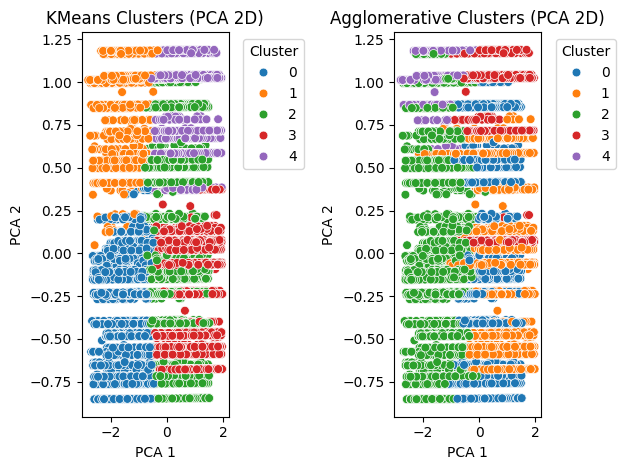

In [18]:
print("\nCluster Size Comparison:")
print("KMeans:\n", df_clustering['KMeans_Cluster'].value_counts().sort_index())
print("Agglomerative:\n", df_clustering['Agglomerative_Cluster'].value_counts().sort_index())
print(f"\nSilhouette Score (KMeans): {sil_kmeans:.3f}")
print(f"Silhouette Score (Agglomerative): {sil_agg:.3f}")

plt.subplot(1, 2, 1)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_clustering['KMeans_Cluster'], palette="tab10", legend="full", s=40)
plt.title('KMeans Clusters (PCA 2D)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.subplot(1, 2, 2)
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df_clustering['Agglomerative_Cluster'], palette="tab10", legend="full", s=40)
plt.title('Agglomerative Clusters (PCA 2D)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend(title='Cluster', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.tight_layout()
plt.show()